# Plant Disease Detection with EfficientNetB3 (TensorFlow / Keras)

**Goal:** classify a leaf image into one of **38 crop–disease classes (14 crops)** using transfer learning from an ImageNet-pretrained **EfficientNetB3**.

**Data plan (~87K images total):**
| Split | Source folder | Size | Used for |
|---|---|---|---|
| Train | `train/` (85%) | ~60K | Learning weights (with flips, rotations, zoom, shifts) |
| Validation | `train/` (15%) | ~10.5K | Early stopping / LR schedule / picking best epoch |
| Test | `valid/` | ~17.5K | **Final, untouched** accuracy reported on the resume |

**Training plan:** Phase 1 trains only a new classification head on a frozen backbone; Phase 2 fine-tunes the top of the backbone at a low learning rate.

> Kaggle setup: **Settings → Accelerator: GPU (T4 or P100)**, **Internet: On** (needed to download ImageNet weights), and **Add Input → "New Plant Diseases Dataset"** (by vipoooool).

## 1. Imports, versions, GPU check, reproducibility

In [4]:
import os, json, random, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus if gpus else "NONE - turn on the GPU accelerator!")

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

TensorFlow: 2.20.0 | Keras: 3.13.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Configuration

In [5]:
IMG_SIZE        = 300        # EfficientNetB3's native input resolution
BATCH_SIZE      = 32
VAL_SPLIT       = 0.15       # 15% of train/ -> validation, 85% (~60K) -> training
EPOCHS_HEAD     = 5          # phase 1: frozen backbone
EPOCHS_FINE     = 15         # phase 2: fine-tuning (EarlyStopping usually stops earlier)
HEAD_LR         = 1e-3
FINE_TUNE_LR    = 3e-5       # 30x smaller: don't wreck pretrained features
UNFREEZE_LAST   = 60         # number of backbone layers to unfreeze in phase 2
DROPOUT         = 0.3
OUT_DIR         = "/kaggle/working" if os.path.isdir("/kaggle/working") else "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Mixed precision (float16 compute) ~2x speed on T4 (compute capability >= 7.0); P100 doesn't benefit.
USE_MIXED_PRECISION = False
if gpus:
    cc = tf.config.experimental.get_device_details(gpus[0]).get("compute_capability", (0, 0))
    USE_MIXED_PRECISION = cc[0] >= 7
if USE_MIXED_PRECISION:
    keras.mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision:", USE_MIXED_PRECISION)

Mixed precision: True


## 3. Locate the dataset

In [6]:
def find_dataset_root(search_root="/kaggle/input"):
    # Returns the first folder containing both 'train' and 'valid' sub-folders.
    for dirpath, dirnames, _ in os.walk(search_root):
        if "train" in dirnames and "valid" in dirnames:
            return dirpath
        dirnames[:] = [d for d in dirnames if d not in ("train", "valid", "test")]  # don't walk into 87K files
    raise FileNotFoundError("Could not find a folder with train/ and valid/ - check the attached dataset.")

DATA_ROOT = find_dataset_root()
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
TEST_DIR  = os.path.join(DATA_ROOT, "valid")   # Kaggle's 'valid' folder is our held-out TEST set
print("Train dir:", TRAIN_DIR)
print("Test dir :", TEST_DIR)

Train dir: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Test dir : /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


## 4. Build `tf.data` pipelines

`image_dataset_from_directory` reads class names from folder names (sorted alphabetically), resizes with **bilinear** interpolation, and yields `uint8`-range float images **0–255**.

**No `/255` here on purpose:** Keras' EfficientNet has its own `Rescaling` + `Normalization` layers built in, so it expects raw 0–255 pixels. Dividing by 255 would feed it the wrong scale (a classic bug).

In [7]:
common = dict(image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
              label_mode="categorical", interpolation="bilinear")

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=VAL_SPLIT, subset="both", seed=SEED, shuffle=True, **common)
test_ds = keras.utils.image_dataset_from_directory(TEST_DIR, shuffle=False, **common)  # fixed order for metrics

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
assert CLASS_NAMES == test_ds.class_names, "Train/test class folders differ!"

TRAIN_FILES, TEST_FILES = train_ds.file_paths, test_ds.file_paths   # keep: prefetch() drops .file_paths
n_train = len(TRAIN_FILES); n_val = len(val_ds.file_paths); n_test = len(TEST_FILES)
N_TOTAL = n_train + n_val + n_test
print(f"Classes: {NUM_CLASSES} | Crops: {len({c.split('___')[0] for c in CLASS_NAMES})}")
print(f"Train: {n_train:,} | Val: {n_val:,} | Test: {n_test:,} | Total: {N_TOTAL:,}")

with open(os.path.join(OUT_DIR, "class_names.json"), "w") as f:
    json.dump(CLASS_NAMES, f, indent=1)   # the Flask app loads this: guarantees index -> name order

Found 70295 files belonging to 38 classes.
Using 59751 files for training.
Using 10544 files for validation.


I0000 00:00:1789149314.801597      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789149314.804689      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 17572 files belonging to 38 classes.
Classes: 38 | Crops: 14
Train: 59,751 | Val: 10,544 | Test: 17,572 | Total: 87,867


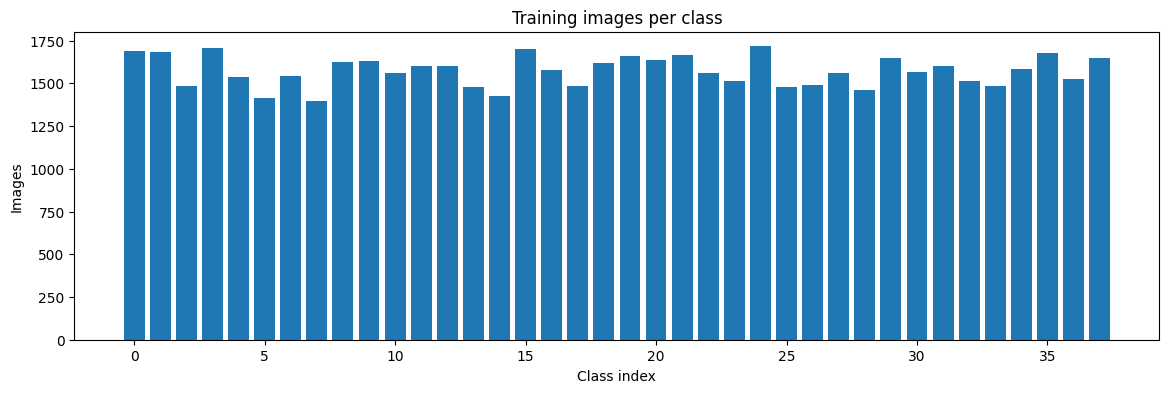

Min/max per class: 1396 / 1716


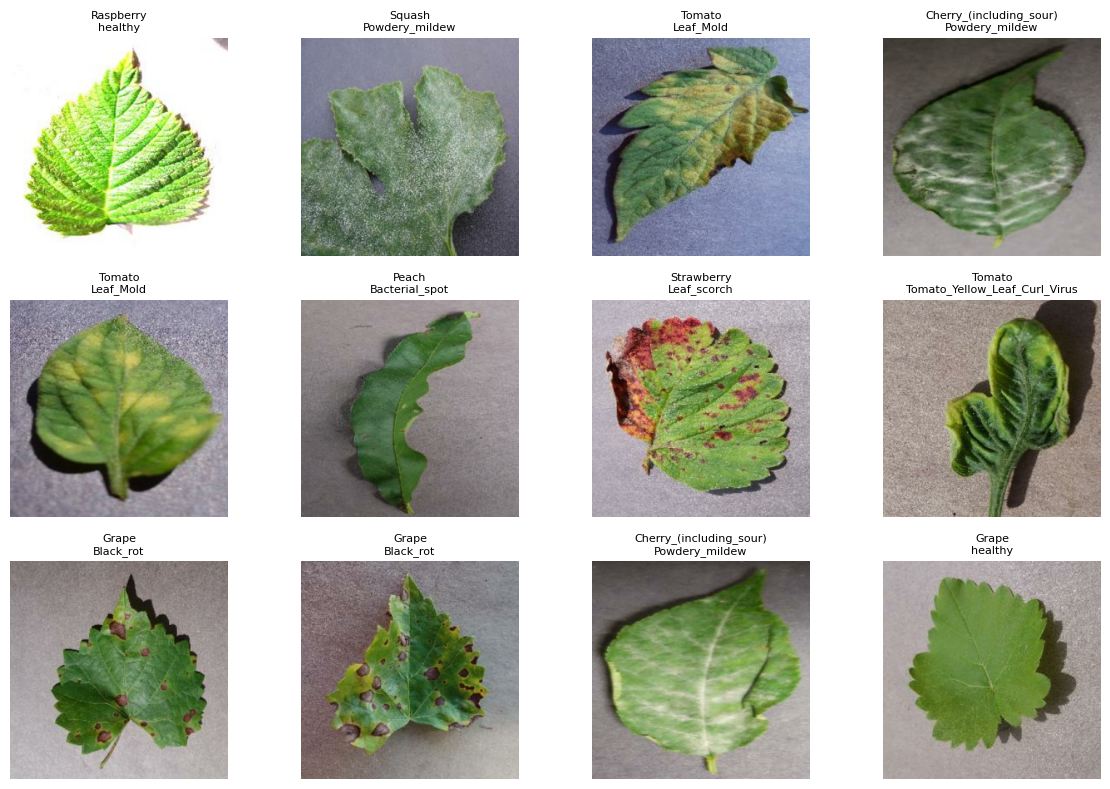

In [8]:
# Class balance + a peek at the data
counts = {c: 0 for c in CLASS_NAMES}
for p in TRAIN_FILES:
    counts[os.path.basename(os.path.dirname(p))] += 1
plt.figure(figsize=(14, 4))
plt.bar(range(NUM_CLASSES), counts.values())
plt.title("Training images per class"); plt.xlabel("Class index"); plt.ylabel("Images")
plt.show()
print(f"Min/max per class: {min(counts.values())} / {max(counts.values())}")

images, labels = next(iter(train_ds))
plt.figure(figsize=(12, 8))
for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(CLASS_NAMES[np.argmax(labels[i])].replace("___", "\n"), fontsize=8)
    plt.axis("off")
plt.tight_layout(); plt.show()

In [9]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)   # load next batch on CPU while GPU trains on current one
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

## 5. Data augmentation: flips, rotations, zoom, shifts

These layers are **random during training only**; at inference (`predict`/`evaluate`) they pass images through unchanged. They run on the GPU as part of the model.

Leaves have no fixed orientation, so flips and rotations don't change the label. They teach the model that disease looks the same at any angle or position.

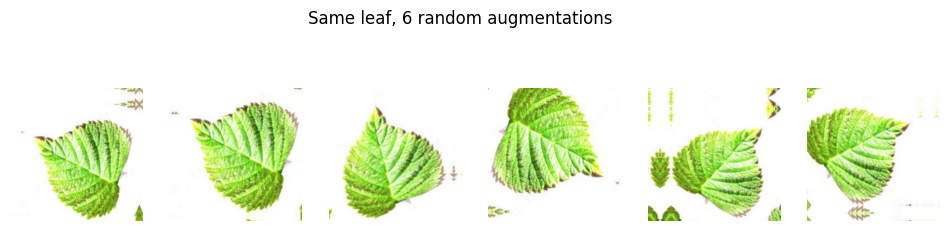

In [10]:
augment = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),            # up to +/-72 degrees (factor is a fraction of 360)
    layers.RandomZoom(0.2),                # zoom in/out up to 20%
    layers.RandomTranslation(0.1, 0.1),    # shift up to 10% vertically / horizontally
], name="augmentation")

sample = images[:1]
plt.figure(figsize=(12, 3))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(augment(sample, training=True)[0].numpy().astype("uint8"))
    plt.axis("off")
plt.suptitle("Same leaf, 6 random augmentations"); plt.show()

## 6. Model: EfficientNetB3 backbone + new classification head

- `include_top=False` drops ImageNet's 1000-class head; we add our own 38-class head.
- `GlobalAveragePooling2D` turns the 10×10×1536 feature map into 1536 numbers (0 parameters, unlike Flatten + big Dense).
- `base(x, training=False)` keeps the backbone's BatchNorm layers in inference mode **even after we unfreeze it**, which is the standard, stable way to fine-tune.
- The last layer is `float32` so softmax stays numerically stable under mixed precision.

In [11]:
base = keras.applications.EfficientNetB3(include_top=False, weights="imagenet",
                                         input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False   # phase 1: freeze the whole backbone

inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
x = augment(inputs)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.BatchNormalization(name="head_bn")(x)
x = layers.Dropout(DROPOUT, name="head_dropout")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32", name="predictions")(x)
model = keras.Model(inputs, outputs, name="effnetb3_plant_disease")

def param_counts(m):
    tr  = sum(int(np.prod(w.shape)) for w in m.trainable_weights)
    ntr = sum(int(np.prod(w.shape)) for w in m.non_trainable_weights)
    return tr, ntr
tr, ntr = param_counts(model)
print(f"Backbone layers: {len(base.layers)} | Total params: {tr+ntr:,} | Trainable now: {tr:,}")

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone layers: 385 | Total params: 10,848,085 | Trainable now: 61,478


## 7. Phase 1: train the head only (backbone frozen)

In [ ]:
def make_callbacks(tag):
    return [
        keras.callbacks.ModelCheckpoint(os.path.join(OUT_DIR, f"best_{tag}.weights.h5"),
                                        monitor="val_accuracy", mode="max",
                                        save_best_only=True, save_weights_only=True, verbose=1),
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7, verbose=1),
        keras.callbacks.CSVLogger(os.path.join(OUT_DIR, "training_log.csv"), append=True),
    ]

METRICS = ["accuracy", keras.metrics.TopKCategoricalAccuracy(k=5, name="top5")]

model.compile(optimizer=keras.optimizers.Adam(HEAD_LR),
              loss="categorical_crossentropy", metrics=METRICS)

t0 = time.time()
history_head = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
                         callbacks=make_callbacks("head"))
print(f"Phase 1 time: {(time.time()-t0)/60:.1f} min")

Epoch 1/5
1868/1868 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.7285 - loss: 0.9677 - top5: 0.9106
Epoch 1: val_accuracy improved from None to 0.91986, saving model to /kaggle/working/best_head.weights.h5

Epoch 1: finished saving model to /kaggle/working/best_head.weights.h5
1868/1868 ━━━━━━━━━━━━━━━━━━━━ 500s 247ms/step - accuracy: 0.8337 - loss: 0.5538 - top5: 0.9697 - val_accuracy: 0.9199 - val_loss: 0.2418 - val_top5: 0.9957 - learning_rate: 0.0010
Epoch 2/5
1868/1868 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.8968 - loss: 0.3325 - top5: 0.9926
Epoch 2: val_accuracy improved from 0.91986 to 0.93067, saving model to /kaggle/working/best_head.weights.h5

Epoch 2: finished saving model to /kaggle/working/best_head.weights.h5
1868/1868 ━━━━━━━━━━━━━━━━━━━━ 434s 232ms/step - accuracy: 0.8985 - loss: 0.3221 - top5: 0.9934 - val_accuracy: 0.9307 - val_loss: 0.2316 - val_top5: 0.9967 - learning_rate: 0.0010
Epoch 3/5
1868/1868 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.90

## 8. Phase 2: fine-tune the top of the backbone

Unfreeze the last `UNFREEZE_LAST` backbone layers, but **keep every BatchNorm layer frozen**. Their running statistics come from ImageNet, and updating them with small batches destabilises training.

Recompiling is required: in Keras, changes to `trainable` only take effect after `compile()`.

In [ ]:
base.trainable = True
for layer in base.layers[:-UNFREEZE_LAST]:
    layer.trainable = False
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

tr, ntr = param_counts(model)
print(f"Trainable params in phase 2: {tr:,} of {tr+ntr:,}")

model.compile(optimizer=keras.optimizers.Adam(FINE_TUNE_LR),
              loss="categorical_crossentropy", metrics=METRICS)

start_epoch = len(history_head.epoch)
t0 = time.time()
history_fine = model.fit(train_ds, validation_data=val_ds,
                         epochs=start_epoch + EPOCHS_FINE, initial_epoch=start_epoch,
                         callbacks=make_callbacks("fine"))
print(f"Phase 2 time: {(time.time()-t0)/60:.1f} min")

## 9. Training curves

Training accuracy is measured **with augmentation and dropout on**, so it can sit slightly below validation accuracy. That's normal, not a bug.

In [ ]:
hist = {k: history_head.history[k] + history_fine.history[k] for k in history_head.history}
ep = range(1, len(hist["loss"]) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for a, metric in zip(ax, ["accuracy", "loss"]):
    a.plot(ep, hist[metric], label=f"train {metric}")
    a.plot(ep, hist[f"val_{metric}"], label=f"val {metric}")
    a.axvline(start_epoch + 0.5, color="gray", ls="--", label="fine-tuning starts")
    a.set_xlabel("Epoch"); a.set_title(metric.capitalize()); a.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=120)
plt.show()

## 10. Evaluation

- **Training accuracy** is reported two ways: last epoch (with augmentation), and a clean re-evaluation with augmentation off.
- **Validation** was used to choose the best epoch, so it's slightly optimistic.
- **Test** (Kaggle's `valid/` folder) was never touched during training, so it is the honest headline number.

In [ ]:
train_eval = model.evaluate(train_ds, verbose=1, return_dict=True)
val_eval   = model.evaluate(val_ds,   verbose=1, return_dict=True)
test_eval  = model.evaluate(test_ds,  verbose=1, return_dict=True)

y_prob = model.predict(test_ds, verbose=1)
y_pred = y_prob.argmax(axis=1)
y_true = np.concatenate([y.numpy().argmax(axis=1) for _, y in test_ds])
macro_f1 = f1_score(y_true, y_pred, average="macro")

print(f"Train acc (last epoch, augmented): {hist['accuracy'][-1]:.4f}")
print(f"Train acc (clean eval)           : {train_eval['accuracy']:.4f}")
print(f"Validation acc                   : {val_eval['accuracy']:.4f}")
print(f"TEST acc                         : {test_eval['accuracy']:.4f} | top-5: {test_eval['top5']:.4f} | macro-F1: {macro_f1:.4f}")

In [ ]:
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(18, 15))
short = [c.replace("___", ": ").replace("_", " ")[:32] for c in CLASS_NAMES]
sns.heatmap(cm_norm, cmap="Blues", xticklabels=short, yticklabels=short, vmin=0, vmax=1)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Normalised confusion matrix (test set)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=110)
plt.show()

off = cm.copy(); np.fill_diagonal(off, 0)
pairs = np.dstack(np.unravel_index(np.argsort(off.ravel())[::-1], off.shape))[0][:10]
print("Most confused pairs (true -> predicted : count)")
for t, p in pairs:
    if off[t, p] > 0:
        print(f"  {CLASS_NAMES[t]}  ->  {CLASS_NAMES[p]} : {off[t, p]}")

## 11. Grad-CAM: where is the model looking?

Grad-CAM weights the last convolutional feature maps by how much they increase the predicted class score. Red regions drove the decision. On a good model they sit on the **lesions**, not the background.

In [ ]:
gap_layer, bn_layer = model.get_layer("gap"), model.get_layer("head_bn")
drop_layer, pred_layer = model.get_layer("head_dropout"), model.get_layer("predictions")

def grad_cam(img):
    x = tf.convert_to_tensor(img[None], dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv = tf.cast(base(x, training=False), tf.float32)       # (1, 10, 10, 1536)
        tape.watch(conv)
        h = drop_layer(bn_layer(gap_layer(conv), training=False), training=False)
        preds = pred_layer(h)
        idx = int(tf.argmax(preds[0]))
        score = preds[:, idx]
    grads = tape.gradient(score, conv)
    weights = tf.reduce_mean(grads, axis=(1, 2))                     # importance of each channel
    cam = tf.nn.relu(tf.reduce_sum(conv * weights[:, None, None, :], axis=-1))[0]
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    cam = tf.image.resize(cam[..., None], (IMG_SIZE, IMG_SIZE))[..., 0].numpy()
    return cam, idx, float(preds[0, idx])

test_images, test_labels = next(iter(test_ds))
plt.figure(figsize=(15, 6))
for i in range(5):
    img = test_images[i].numpy()
    cam, idx, conf = grad_cam(img)
    plt.subplot(2, 5, i + 1); plt.imshow(img.astype("uint8")); plt.axis("off")
    plt.title("True: " + CLASS_NAMES[np.argmax(test_labels[i])].split("___")[1][:18], fontsize=8)
    plt.subplot(2, 5, i + 6); plt.imshow(img.astype("uint8")); plt.imshow(cam, cmap="jet", alpha=0.45); plt.axis("off")
    plt.title(f"Pred: {CLASS_NAMES[idx].split('___')[1][:18]} ({conf:.0%})", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "gradcam_examples.png"), dpi=110)
plt.show()

## 12. Export a clean inference model for the Flask app

The exported model has **no augmentation layers, no optimizer state, and float32 weights** (runs on any CPU). It's about 45–50 MB, under GitHub's 100 MB limit, so **Git LFS is no longer needed**.

In [ ]:
keras.mixed_precision.set_global_policy("float32")
inf_base = keras.applications.EfficientNetB3(include_top=False, weights=None,
                                             input_shape=(IMG_SIZE, IMG_SIZE, 3))
inf_base.set_weights(base.get_weights())
inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
y = inf_base(inp, training=False)
y = layers.GlobalAveragePooling2D(name="gap")(y)
y = layers.BatchNormalization(name="head_bn")(y)
y = layers.Dropout(DROPOUT, name="head_dropout")(y)
out = layers.Dense(NUM_CLASSES, activation="softmax", name="predictions")(y)
inference_model = keras.Model(inp, out, name="effnetb3_plant_disease_inference")
for name in ["head_bn", "predictions"]:
    inference_model.get_layer(name).set_weights(model.get_layer(name).get_weights())

# Sanity check: exported model must agree with the trained model
check = test_images[:8]
diff = np.abs(inference_model.predict(check, verbose=0) - model.predict(check, verbose=0)).max()
print(f"Max prediction difference (should be tiny): {diff:.5f}")

MODEL_PATH = os.path.join(OUT_DIR, "plant_disease_effnetb3.keras")
inference_model.save(MODEL_PATH)
print(f"Saved {MODEL_PATH} ({os.path.getsize(MODEL_PATH)/1e6:.1f} MB)")

## 13. Single-image prediction (identical to what the Flask app does)

In [ ]:
from PIL import Image

def predict_leaf(path, threshold=0.60):
    img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    x = np.asarray(img, dtype=np.float32)[None]          # (1, 300, 300, 3), 0-255, NO /255
    probs = inference_model.predict(x, verbose=0)[0]
    top3 = probs.argsort()[::-1][:3]
    crop, disease = CLASS_NAMES[top3[0]].split("___")
    status = "confident" if probs[top3[0]] >= threshold else "uncertain - retake photo"
    return crop, disease.replace("_", " "), float(probs[top3[0]]), status, [(CLASS_NAMES[i], float(probs[i])) for i in top3]

sample_path = TEST_FILES[0]
print(sample_path.split("/")[-2], "->", predict_leaf(sample_path))

## 14. Final numbers (copy these into your resume and README)

In [ ]:
summary = {
    "total_images": N_TOTAL, "train_images": n_train, "val_images": n_val, "test_images": n_test,
    "classes": NUM_CLASSES, "crops": len({c.split('___')[0] for c in CLASS_NAMES}),
    "train_acc_last_epoch": round(hist["accuracy"][-1], 4),
    "train_acc_clean": round(train_eval["accuracy"], 4),
    "val_acc": round(val_eval["accuracy"], 4),
    "test_acc": round(test_eval["accuracy"], 4),
    "test_top5": round(test_eval["top5"], 4),
    "test_macro_f1": round(macro_f1, 4),
    "epochs_run": len(hist["loss"]),
    "tf_version": tf.__version__, "keras_version": keras.__version__,
}
with open(os.path.join(OUT_DIR, "results.json"), "w") as f:
    json.dump(summary, f, indent=2)
for k, v in summary.items():
    print(f"{k:22s}: {v}")

print("\nResume bullets filled with YOUR numbers:")
print(f"- EfficientNetB3 TensorFlow model for plant disease detection across {summary['classes']} classes "
      f"({summary['crops']} crops), trained on {N_TOTAL/1000:.0f}K images; {summary['test_acc']*100:.2f}% held-out test accuracy")
print(f"- Fine-tuned ImageNet-pretrained EfficientNetB3 in two phases (frozen head training, then top-layer fine-tuning)")
print(f"- Augmented {n_train/1000:.0f}K training images with flips, rotations, zoom and shifts to improve generalization")
print(f"- {summary['train_acc_clean']*100:.2f}% train, {summary['val_acc']*100:.2f}% validation, "
      f"{summary['test_acc']*100:.2f}% test accuracy; {summary['test_macro_f1']*100:.2f}% macro-F1 on {n_test/1000:.1f}K unseen images")

## Files to download from `/kaggle/working` → put in your GitHub repo
`plant_disease_effnetb3.keras`, `class_names.json`, `results.json`, `training_curves.png`, `confusion_matrix.png`, `gradcam_examples.png`, `training_log.csv`, and **this notebook with outputs saved** (Kaggle: *Save Version → Save & Run All*, then *File → Download notebook*).